# Convolutional Neural Network Demo

A **convolutional neural network (CNN)** learns spatial features before classifying an image. This example trains a small network on MNIST handwritten digits, evaluates held-out accuracy, and displays misclassified examples.

Run the cells in order with PyTorch, torchvision, and Matplotlib installed. The first run needs internet access to download MNIST. Training uses CUDA when available and otherwise the CPU; the supplied setting is one epoch.


## Imports and Random Seed

The data loader batches examples, <code>torch.nn</code> supplies layers and loss functions, and <code>torch.optim</code> supplies the optimizer. The seed helps reproduce initialization and shuffling, although results can still vary across devices and software versions.


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# set random seed for reproducibility
torch.manual_seed(42)



## Define Layers and the Forward Pass

`__init__` creates the learnable layers. `forward` specifies how an input moves through them. The class stays together as a complete Python definition.

PyTorch uses tensor order <code>(batch, channels, height, width)</code>. For a batch of size B, the shape changes are:

| Stage | Output shape | Role |
|---|---|---|
| Input | B x 1 x 28 x 28 | Grayscale images |
| First convolution + ReLU | B x 32 x 28 x 28 | Local feature maps |
| Second convolution + ReLU | B x 64 x 28 x 28 | Combine local features |
| Max pooling | B x 64 x 14 x 14 | Reduce spatial resolution |
| Flatten | B x 12544 | One feature vector per image |
| Fully connected + ReLU | B x 128 | Learned classifier features |
| Dropout + output layer | B x 10 | One score per digit |

**ReLU** means rectified linear unit. Padding preserves spatial size in both convolutions; pooling occurs only after the second. Dropout randomly suppresses hidden activations during training. The final scores are **logits**, not probabilities.


In [ ]:
# Define the CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1) # size 28x28x1 -> 28x28x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1) # size 28x28x32 -> 28x28x64
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # size 28x28x64 -> 14x14x64
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 14 * 14)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x



## Load and Normalize Images

MNIST is the Modified National Institute of Standards and Technology digit dataset. Tensor conversion maps pixels to [0, 1]; normalization maps them to [-1, 1]. Both data splits use identical preprocessing.

Unlike the KNN notebook's single-batch subset, these loaders are iterated over completely. Training batches are shuffled; test batches are not. A smaller final batch is allowed.


In [ ]:
# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='~/temp_data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='~/temp_data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)



## Model, Loss, and Optimizer

The model and each batch must be on the same device. <code>CrossEntropyLoss</code> consumes raw logits and integer class labels; do not insert a softmax before this loss.

Adam updates the model's parameters using gradients and running moment estimates. Its learning rate is 0.001. Constructing the optimizer does not train the model.


In [ ]:
# Initialize model, loss function, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



## Train for One Epoch

One epoch visits the whole training set once. <code>model.train()</code> enables training behavior, including dropout. For each batch:

1. Move images and labels to the selected device.
2. Clear old gradients with <code>zero_grad()</code>.
3. Compute logits and cross-entropy loss.
4. Backpropagate with <code>loss.backward()</code>.
5. Update parameters with <code>optimizer.step()</code>.

The printed loss is the mean of batch loss values. Since the last batch can be smaller, it is not an exactly sample-weighted dataset mean.


In [ ]:
# Training loop
num_epochs = 1
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")



Epoch 1/1, Loss: 0.2424318811405442


## Prepare Held-Out Evaluation

<code>model.eval()</code> disables dropout. Counters record the number of correct predictions and total test examples. The lists retain the first three errors for later inspection.

Evaluation mode and gradient tracking are different controls: the next cell also uses <code>no_grad()</code> to avoid building backward graphs.


In [ ]:
# Evaluation
model.eval()
correct = 0
total = 0
wrong_images = []
wrong_labels = []
wrong_predictions = []



## Predict Without Updating Weights

For each image, the index of the largest logit is the predicted digit. Correct predictions are counted across the entire test set. Misclassified images and labels are copied back to the CPU for plotting.

No backward call or optimizer step occurs here. The test labels measure performance; they are not used to train on these examples.


In [ ]:
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if len(wrong_images) < 3:  # Collect wrong predictions
            # Collect wrong predictions
            for i in range(len(labels)):
                if predicted[i] != labels[i]:
                    wrong_images.append(images[i].cpu())
                    wrong_labels.append(labels[i].cpu())
                    wrong_predictions.append(predicted[i].cpu())
                    if len(wrong_images) == 3:  # Stop after collecting 3 wrong images
                        break



## Inspect Misclassifications

The displayed images are the first three errors encountered, not a random or representative sample. Compare the true and predicted digits: an aggregate accuracy cannot reveal the appearance of individual failures.

This plotting code assumes that at least three errors were collected, which holds for the saved run. A more accurate model or a smaller evaluation subset would need a length check.


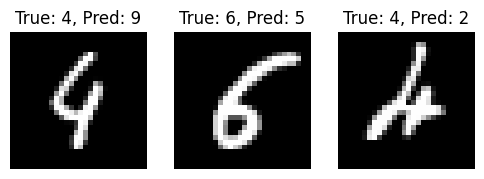

In [ ]:
# Display 3 wrong images
fig, axes = plt.subplots(1, 3, figsize=(6, 2))
for i, ax in enumerate(axes):
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.set_title(f"True: {wrong_labels[i].item()}, Pred: {wrong_predictions[i].item()}")
    ax.axis('off')
plt.show()



## Report Test Accuracy

Accuracy divides the total number correct by the number of test images, then expresses the result as a percentage. This is held-out performance after one epoch, not training accuracy.


In [ ]:
print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 98.47%


## Connect the Pieces

- How do shared convolutional kernels differ from connecting every input pixel to every hidden unit?
- Why must the input size of <code>fc1</code> change if the pooling layout changes?
- What happens to prediction variability if dropout is accidentally left in training mode?
- Use validation data, not the final test set, when choosing epochs or architecture changes.

<details class="notebook-answers">
<summary>Answers and discussion</summary>

1. **Convolutions combine locality with shared weights.** A 3-by-3 kernel connects to a local patch and reuses the same weights at every spatial position. A dense layer assigns separate weights to each input-to-output connection. Sharing makes a feature detector usable across the image with fewer parameters than an unrestricted dense mapping to the same spatial outputs.
2. **Pooling determines the flattened feature count.** Currently the final feature map is `64 x 14 x 14`, so `fc1` expects 12,544 inputs per image. Adding another 2-by-2, stride-2 pooling stage would reduce it to `64 x 7 x 7`, or 3,136 inputs. Both the flattening expression in `forward` and the input dimension of `fc1` must match the new shape; otherwise the tensor operations or batch dimensions will be wrong.
3. **Training-mode dropout makes predictions stochastic.** Each forward pass samples a new mask, so repeated predictions for the same image can have different logits and sometimes different labels. `model.eval()` disables dropout for ordinary evaluation. `torch.no_grad()` alone does not disable it: gradient tracking and training/evaluation behavior are independent.
4. **Validation supports model selection; testing estimates generalization.** Reserve part of the training data for comparing epoch counts, architectures, and other choices. After those choices are fixed, evaluate on the untouched test set. Repeatedly changing the model in response to test accuracy effectively uses the test set for tuning and weakens its role as an independent final check.

</details>

**Takeaway:** a working training pipeline needs consistent shapes, the correct loss inputs, explicit gradient updates, and a separate evaluation mode.
